In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
def standardiseData(data, lowerBound = 0.1, upperBound = 0.9):
    normData = np.zeros(data.shape)
    for rowIndex, row in enumerate(data):
        normData[rowIndex, :] = (upperBound - lowerBound) * ((row - np.min(row)) / (np.max(row) - np.min(row))) + lowerBound
    return normData


def deStandardiseData(data, dataMax, dataMin, lowerBound = 0.1, upperBound = 0.9):
    data = np.zeros(data.shape)
    for colIndex, column in enumerate(np.transpose(data)):
        data[:, colIndex] = ((column - lowerBound) / upperBound) * (dataMax - dataMin) + dataMin
    return data


In [4]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 7.5, 0.01)

In [5]:
kanODE.train(3000, solverMethod="rk4")

100%|██████████| 3000/3000 [3:29:26<00:00,  4.19s/it]  


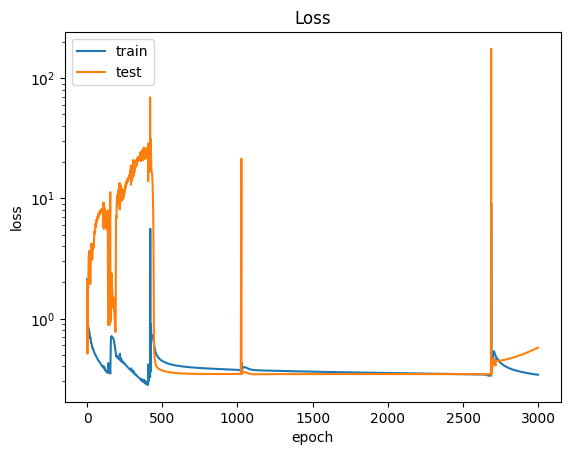

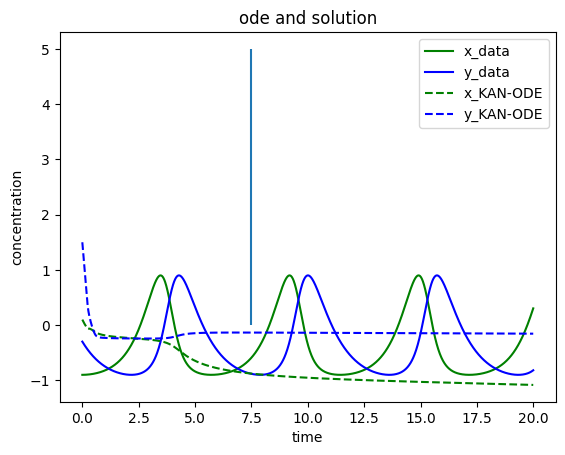

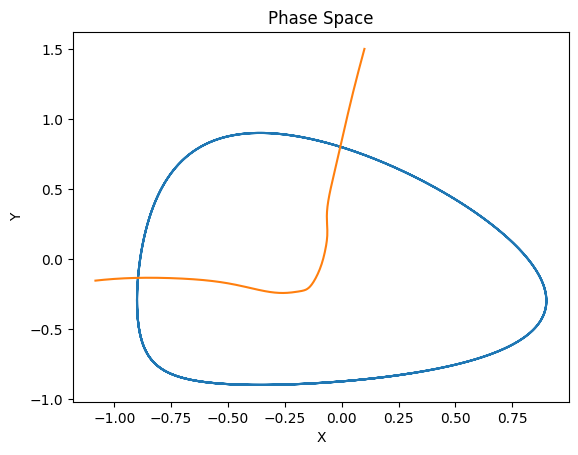

In [6]:
_, solution = kanODE.test("rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])